1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


2. Load Dataset

In [2]:
df = pd.read_csv('retail_customer_segmentation.csv')
df.head()

,customer_id,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions,payment_method,region,customer_segment
0,33554,53,100473.211709,63,121.430565,0.817268,66.820403,0.117256,0.023144,77.298393,2.0,Card,Semi-Urban,Occasional
1,9428,54,54730.644845,67,572.552674,3.176551,137.087449,0.261647,0.429054,92.132565,2.0,Wallet,Urban,Occasional
2,200,44,58268.121079,57,266.593896,2.713168,71.796888,0.284785,0.011854,155.194768,1.0,UPI,Rural,Occasional
3,12448,54,64829.795654,40,691.452358,5.553977,105.501185,0.104832,0.399686,113.917756,0.0,Wallet,Rural,High_Value
4,39490,28,27431.467873,15,832.664792,1.348389,354.568534,0.409204,0.039517,50.123656,1.0,Card,Semi-Urban,Occasional


3. Data Understanding\
3.1. Data Inspection

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            50000 non-null  int64  
 1   age                    50000 non-null  int64  
 2   annual_income          46925 non-null  float64
 3   months_active          50000 non-null  int64  
 4   avg_monthly_spend      47480 non-null  float64
 5   purchase_frequency     48021 non-null  float64
 6   avg_order_value        50000 non-null  float64
 7   discount_usage_rate    47451 non-null  float64
 8   return_rate            47513 non-null  float64
 9   browsing_time_minutes  46066 non-null  float64
 10  support_interactions   48012 non-null  float64
 11  payment_method         50000 non-null  object 
 12  region                 50000 non-null  object 
 13  customer_segment       50000 non-null  object 
dtypes: float64(8), int64(3), object(3)
memory usage: 5.3+ 

**Feature Description**
<div style="font-size: 0.8em;">
  
| Column Name | Type | Description |
| :--- | :--- | :--- |
| `customer_id` | Integer | Unique customer identifier. |
| `age` | Integer | Customer age (18–70). |
| `annual_income` | Float | Log-normally distributed income. |
| `months_active` | Integer | Number of months active. |
| `avg_monthly_spend` | Float | Average monthly expenditure. |
| `purchase_frequency` | Float | Average purchases per month. |
| `avg_order_value` | Float | `avg_monthly_spend` / (`purchase_frequency` + 1) |
| `discount_usage_rate` | Float | Proportion of purchases using discounts (0–1). |
| `return_rate` | Float | Proportion of return purchased (0-1). |
| `browsing_time_minutes` | Float | Avg browsing time per session. |
| `support_interactions` | Float | Support contacts (Poisson distributed). |
| `payment_method` | Categorical | `Card`, `UPI`, `Wallet`. |
| `region` | Categorical | `Urban`, `Semi-Urban`, `Rural`. |
| `customer_segment` | Categorical | Target variable. |

Most likely Interpretation:
- `puchase_frequency`: average purchases per month (total_purchase / months_active)
- `avg_order_value`: Not the traditional (sales/amt). It is an approximation of that, by taking the `avg_monthly_spend` / (`purchase_frequency` + 1)
- `discount_usage_rate`: Our of all purchases by a specific customer, what % of those used a discount?
- `return_rate`: Out of all purchases by a customer, what % of purchases were returned (for refund, exchange...)?
</div>



Let's drop `customer_id`. It won't help us with analysis

In [4]:
df = df.drop(columns='customer_id')

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,50000.0,44.002820,15.269871,18.000000,31.000000,44.000000,57.000000,70.000000
annual_income,46925.0,44542.620904,30537.946035,2946.317892,24373.244554,36787.730010,55497.245522,530788.317921
months_active,50000.0,36.477480,20.787197,1.000000,18.000000,36.000000,55.000000,72.000000
avg_monthly_spend,47480.0,337.294238,204.627095,8.072298,192.074544,297.477404,439.112361,3026.342238
purchase_frequency,48021.0,4.910841,3.416115,0.017013,2.456867,4.158673,6.526903,67.682528
avg_order_value,50000.0,77.375915,70.531793,0.940393,32.018468,56.600351,98.832037,1289.427328
discount_usage_rate,47451.0,0.284358,0.159236,0.000534,0.160497,0.262591,0.387640,0.934655
return_rate,47513.0,0.148964,0.110508,0.000050,0.063938,0.123628,0.209612,0.830395
browsing_time_minutes,46066.0,61.781329,41.743394,0.236109,31.082283,52.679175,82.549571,406.813006
support_interactions,48012.0,1.494606,1.221280,0.000000,1.000000,1.000000,2.000000,9.000000


In [6]:
num_cols = df.select_dtypes(include='number').columns
num_cols

Index(['age', 'annual_income', 'months_active', 'avg_monthly_spend',
       'purchase_frequency', 'avg_order_value', 'discount_usage_rate',
       'return_rate', 'browsing_time_minutes', 'support_interactions'],
      dtype='object')

In [7]:
for var in num_cols:
    print(f"Mean   of {var}: {df[var].mean():.2f}")
    print(f"Median of {var}: {df[var].median():.2f}")
    print()

Mean   of age: 44.00
Median of age: 44.00

Mean   of annual_income: 44542.62
Median of annual_income: 36787.73

Mean   of months_active: 36.48
Median of months_active: 36.00

Mean   of avg_monthly_spend: 337.29
Median of avg_monthly_spend: 297.48

Mean   of purchase_frequency: 4.91
Median of purchase_frequency: 4.16

Mean   of avg_order_value: 77.38
Median of avg_order_value: 56.60

Mean   of discount_usage_rate: 0.28
Median of discount_usage_rate: 0.26

Mean   of return_rate: 0.15
Median of return_rate: 0.12

Mean   of browsing_time_minutes: 61.78
Median of browsing_time_minutes: 52.68

Mean   of support_interactions: 1.49
Median of support_interactions: 1.00



- OK: `age`, `months_active`, `return_rate`
- Quite OK: `purchase_frequency` (to the left)
- outlier to the right: `annual_income`, `avg_order_value`, `browsing_time_minutes`
- outlier to the left: 

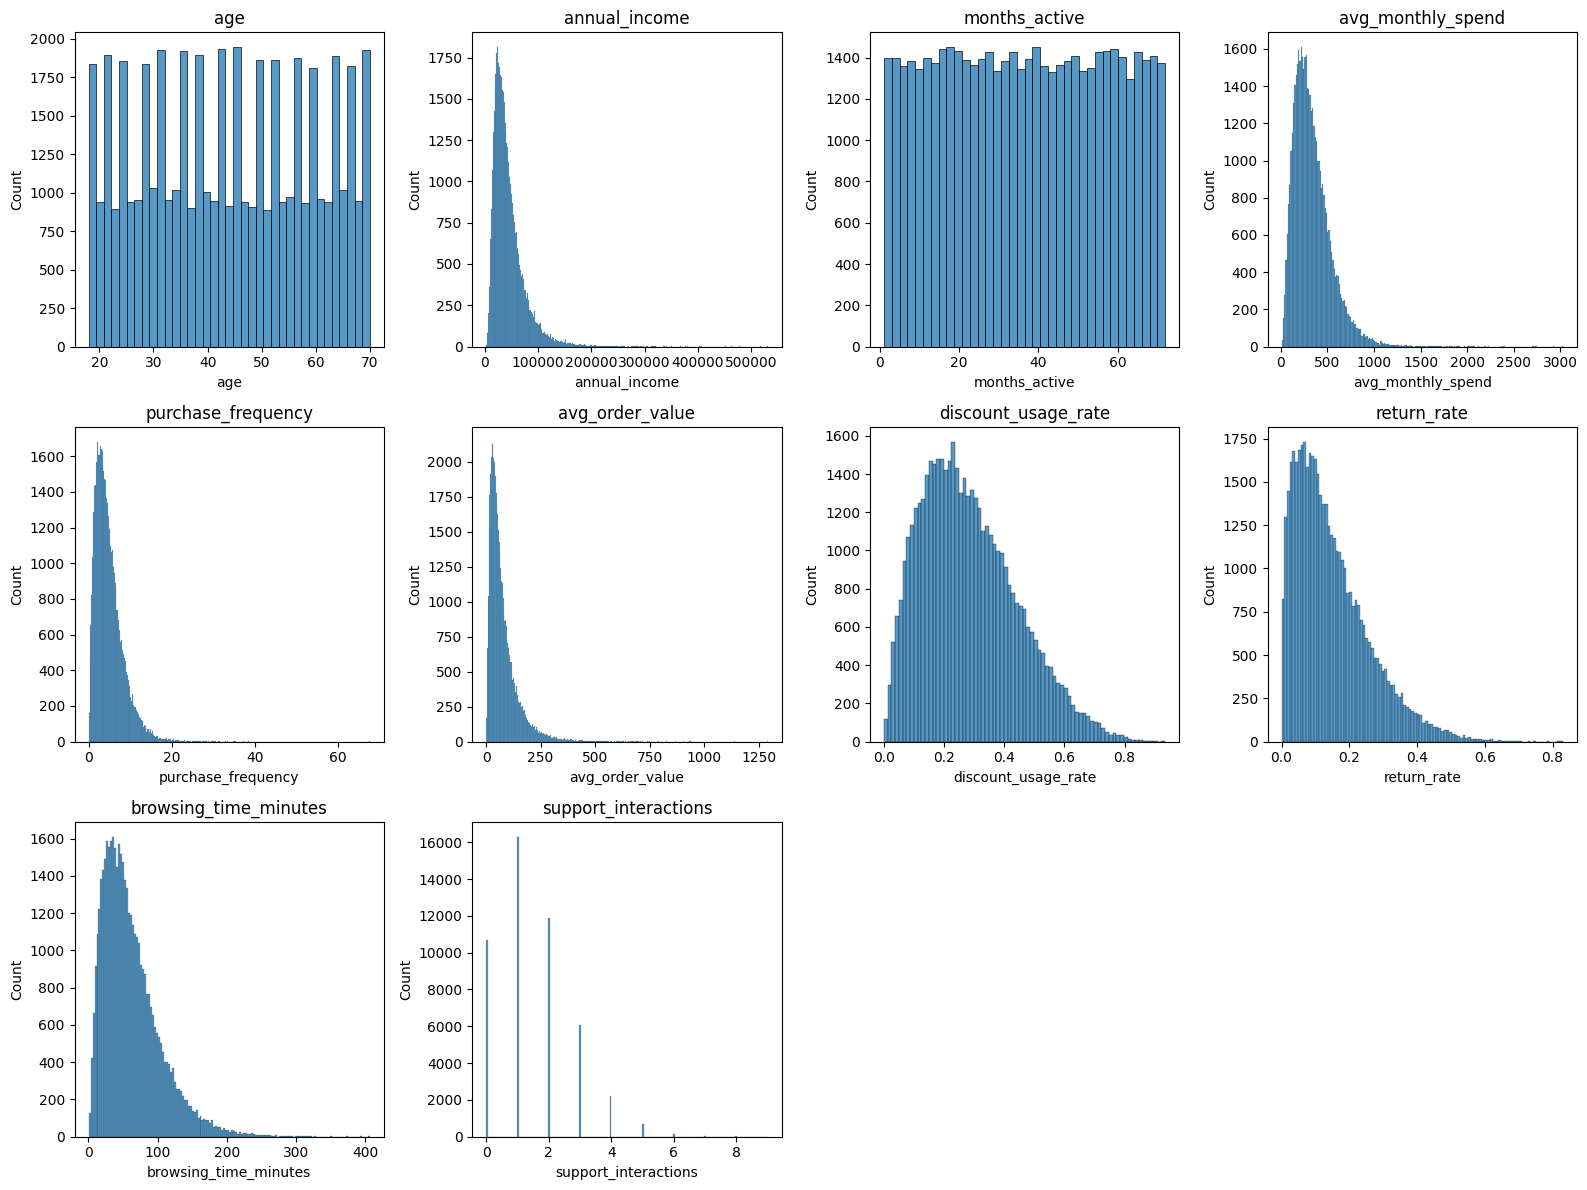

In [8]:
rows = (len(num_cols) + 3) // 4 # dynamic rows 
_, axes = plt.subplots(rows, 4, figsize=(16, 4 * rows))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.histplot(df, x=col, bins='auto', ax=ax)
    ax.set_title(col)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [9]:
cat_cols = df.select_dtypes(exclude='number').columns
cat_cols

Index(['payment_method', 'region', 'customer_segment'], dtype='object')

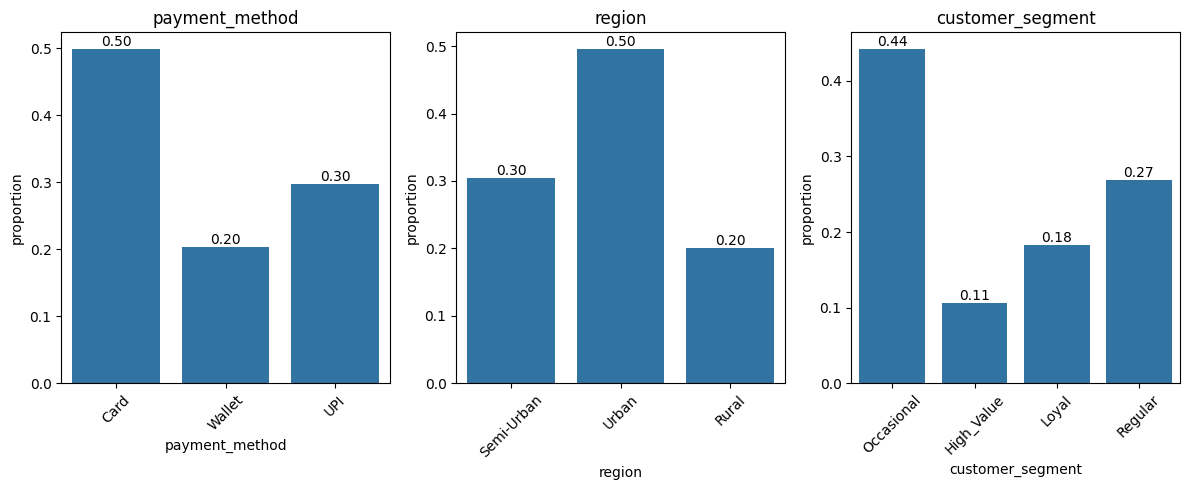

In [10]:
# Graphical Representation of qualitative columns

_, axes = plt.subplots(1, 3, figsize=(12, 5))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    sns.countplot(data=df, x=col, ax=ax, stat='proportion')
    ax.bar_label(ax.containers[0], fmt='%.2f')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

---

## **Handling Null Values**

Identifying Missing values in each column

In [11]:
na_by_cols = df.isna().sum() / df.shape[0] * 100

In [12]:
na_by_cols.sort_values(ascending=False)

browsing_time_minutes    7.868
annual_income            6.150
discount_usage_rate      5.098
avg_monthly_spend        5.040
return_rate              4.974
support_interactions     3.976
purchase_frequency       3.958
months_active            0.000
age                      0.000
avg_order_value          0.000
payment_method           0.000
region                   0.000
customer_segment         0.000
dtype: float64

If we go by the rule of thumb, we can safely remove the rows with missing values on columns with less that 5% missing values, and potentially drop the ones below 10% percent as well. 

In [13]:
rows_with_missing = df.isna().any(axis=1).sum()
proportion_rows_with_missing = df.isna().any(axis=1).mean()
print(proportion_rows_with_missing)

0.31722


However, we found that combined 31.72% of the rows have at least one missing value, which is a lot, so removing them would result in significant loss in healthy data in other columns. 

- So let's study the nature of the missing data first before we decide on how to handle it.

### **Studying Missingness Nature**

We will study the distribution of columns without missing data before and after the removal of rows with missing values to see if there is a significant difference in the distribution, which would indicate that the missing data is not random and may be related to the values in those columns.

In [14]:
NA_list = []
NoNA_list = []

for i in range(len(na_by_cols)):
    if na_by_cols.values[i] > 0:
        NA_list.append(na_by_cols.index[i])
    else:
        NoNA_list.append(na_by_cols.index[i])

In [15]:
# Columns that has missing values

NA_list

['annual_income',
 'avg_monthly_spend',
 'purchase_frequency',
 'discount_usage_rate',
 'return_rate',
 'browsing_time_minutes',
 'support_interactions']

In [16]:
# Columns with no missing values

NoNA_list

['age',
 'months_active',
 'avg_order_value',
 'payment_method',
 'region',
 'customer_segment']

In [17]:
# Dropping the rows with missing value for comparison

cleaned_data = df.dropna()

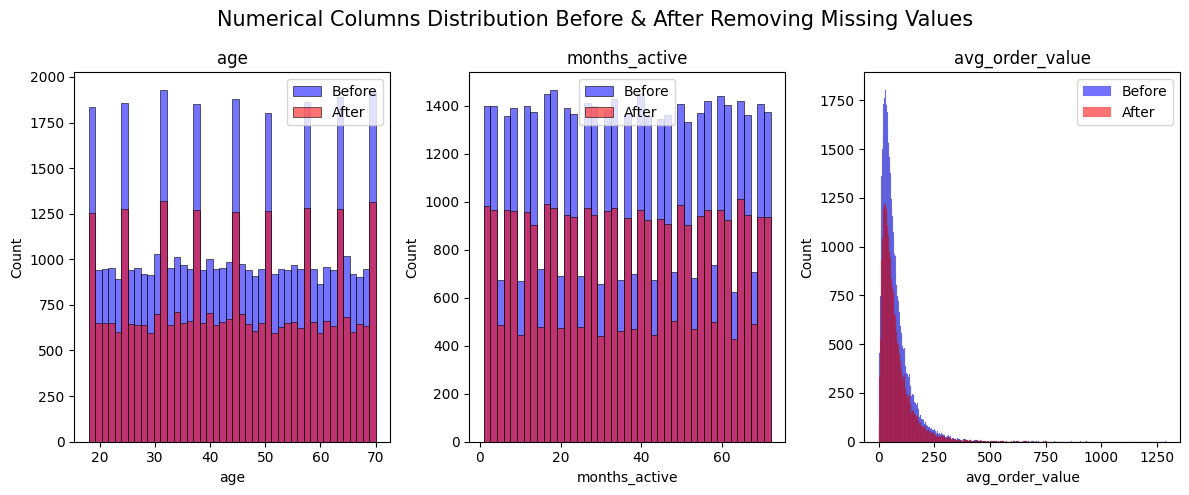

In [18]:
num_NoNA = [col for col in NoNA_list if col in num_cols]

_, axes = plt.subplots(1, 3, figsize=(12, 5))
axes_flat = axes.flatten()

for ax, col in zip(axes_flat, num_NoNA):
    combined = pd.concat([df[col], cleaned_data[col]]).dropna()
    _, bin_edges = np.histogram(combined, bins='auto')

    sns.histplot(df, x=col, ax=ax, bins=bin_edges, label='Before', alpha=0.55, color='blue')
    sns.histplot(cleaned_data, x=col, ax=ax, bins=bin_edges, label='After', alpha=0.55, color='red')
    ax.set_title(col)
    ax.legend()

plt.suptitle('Numerical Columns Distribution Before & After Removing Missing Values', fontsize=15)
plt.tight_layout()
plt.show()

We can see that is **no significant difference** in the distribution of the numerical columns without missing data before and after the removal of rows with missing values and they actually closely follow the same distribution, which indicates that the missing data is random and not related to the values in those columns. 

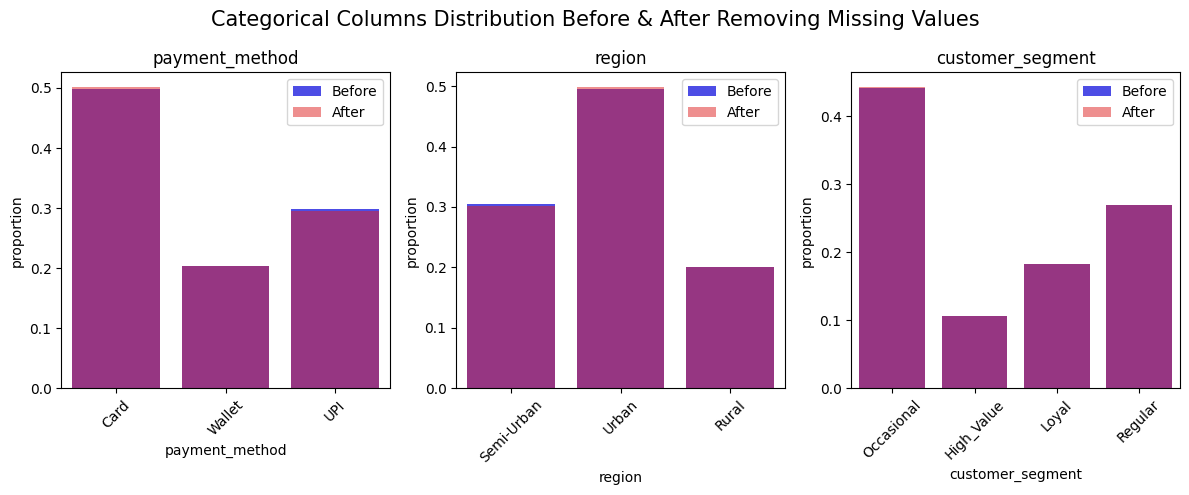

In [19]:
cat_NoNA = [col for col in NoNA_list if col not in num_cols]

_, axes = plt.subplots(1, 3, figsize=(12, 5))
axes_flat = axes.flatten()

for ax, col in zip(axes_flat, cat_NoNA):
    sns.countplot(data=df, x=col, ax=ax, stat='proportion', label='Before', color='blue', alpha=0.8)
    sns.countplot(data=cleaned_data, x=col, ax=ax, stat='proportion', label='After', color='red', alpha=0.5)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
    ax.legend()

plt.suptitle('Categorical Columns Distribution Before & After Removing Missing Values', fontsize=15)
plt.tight_layout()
plt.show()

Similarly, the non-missing categorical columns also see no proportion change after the removal of rows with missing values, which further supports the conclusion that the missing data is random and not related to the values in those columns.

From this, we can conclude that the nature of the missingness is ***Missing Completely at Random (MCAR)***

- Therefore, we should be able to safely remove the rows with missing values without introducing bias to our analysis.a

But then again, from earlier, removing them all is removing 31% of our total 50,000 rows, so I think it wouldn't hurt to just **impute them with the median** instead

In [20]:
cleaned = df.copy()

cleaned[NA_list] = df[NA_list].fillna(df[NA_list].median())

In [21]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer

# Preserves relationships between variables
imputer = IterativeImputer(random_state=42, max_iter=10)
cleaned[NA_list] = imputer.fit_transform(df[NA_list])

In [22]:
cleaned.isna().sum()

age                      0
annual_income            0
months_active            0
avg_monthly_spend        0
purchase_frequency       0
avg_order_value          0
discount_usage_rate      0
return_rate              0
browsing_time_minutes    0
support_interactions     0
payment_method           0
region                   0
customer_segment         0
dtype: int64

In [23]:
df[NA_list] = df[NA_list].fillna(df[NA_list].median())

In [24]:
df.isna().sum()

age                      0
annual_income            0
months_active            0
avg_monthly_spend        0
purchase_frequency       0
avg_order_value          0
discount_usage_rate      0
return_rate              0
browsing_time_minutes    0
support_interactions     0
payment_method           0
region                   0
customer_segment         0
dtype: int64

---

## **Handling Outliers**

Checking min and max values of numerical columns to identify potential outliers

In [25]:
cleaned[NA_list].describe()

,annual_income,avg_monthly_spend,purchase_frequency,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,44542.693695,337.293988,4.910814,0.284358,0.148964,61.781257,1.494601
std,29583.986898,199.403846,3.347832,0.155125,0.107725,40.067581,1.196756
min,2946.317892,8.072298,0.017013,0.000534,0.000050,0.236109,0.000000
25%,25112.704208,197.220824,2.526421,0.166100,0.066834,32.836514,1.000000
50%,38710.586730,309.826593,4.316086,0.273924,0.130674,56.794457,1.000000
75%,53830.215138,429.191654,6.399534,0.380198,0.203893,79.367471,2.000000
max,530788.317921,3026.342238,67.682528,0.934655,0.830395,406.813006,9.000000


In [26]:
df[NA_list].describe()

,annual_income,avg_monthly_spend,purchase_frequency,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000
mean,44065.695114,335.287469,4.881070,0.283248,0.147704,61.065171,1.47494
std,29642.592692,199.593893,3.351036,0.155198,0.107865,40.142412,1.20065
min,2946.317892,8.072298,0.017013,0.000534,0.000050,0.236109,0.00000
25%,25112.704208,197.220824,2.526421,0.166100,0.066834,32.836514,1.00000
50%,36787.730010,297.477404,4.158673,0.262591,0.123628,52.679175,1.00000
75%,53830.215138,429.191654,6.399534,0.380198,0.203893,79.367471,2.00000
max,530788.317921,3026.342238,67.682528,0.934655,0.830395,406.813006,9.00000


In [27]:
data = pd.read_csv("retail_customer_segmentation.csv")[NA_list].describe()
data

,annual_income,avg_monthly_spend,purchase_frequency,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions
count,46925.000000,47480.000000,48021.000000,47451.000000,47513.000000,46066.000000,48012.000000
mean,44542.620904,337.294238,4.910841,0.284358,0.148964,61.781329,1.494606
std,30537.946035,204.627095,3.416115,0.159236,0.110508,41.743394,1.221280
min,2946.317892,8.072298,0.017013,0.000534,0.000050,0.236109,0.000000
25%,24373.244554,192.074544,2.456867,0.160497,0.063938,31.082283,1.000000
50%,36787.730010,297.477404,4.158673,0.262591,0.123628,52.679175,1.000000
75%,55497.245522,439.112361,6.526903,0.387640,0.209612,82.549571,2.000000
max,530788.317921,3026.342238,67.682528,0.934655,0.830395,406.813006,9.000000


The `InterativeImputer` seems to be *a bit*, just a bit more accurate to the stats of the original value

In [28]:
num_cols

Index(['age', 'annual_income', 'months_active', 'avg_monthly_spend',
       'purchase_frequency', 'avg_order_value', 'discount_usage_rate',
       'return_rate', 'browsing_time_minutes', 'support_interactions'],
      dtype='object')

In [29]:
for var in num_cols:
    print(f"Mean   of {var}: {df[var].mean():.2f}")
    print(f"Median of {var}: {df[var].median():.2f}")
    print()

Mean   of age: 44.00
Median of age: 44.00

Mean   of annual_income: 44065.70
Median of annual_income: 36787.73

Mean   of months_active: 36.48
Median of months_active: 36.00

Mean   of avg_monthly_spend: 335.29
Median of avg_monthly_spend: 297.48

Mean   of purchase_frequency: 4.88
Median of purchase_frequency: 4.16

Mean   of avg_order_value: 77.38
Median of avg_order_value: 56.60

Mean   of discount_usage_rate: 0.28
Median of discount_usage_rate: 0.26

Mean   of return_rate: 0.15
Median of return_rate: 0.12

Mean   of browsing_time_minutes: 61.07
Median of browsing_time_minutes: 52.68

Mean   of support_interactions: 1.47
Median of support_interactions: 1.00



Surprisingly, we got same statistical value before and after imputing (prolly the dataset's author wanted it this way, I guess)

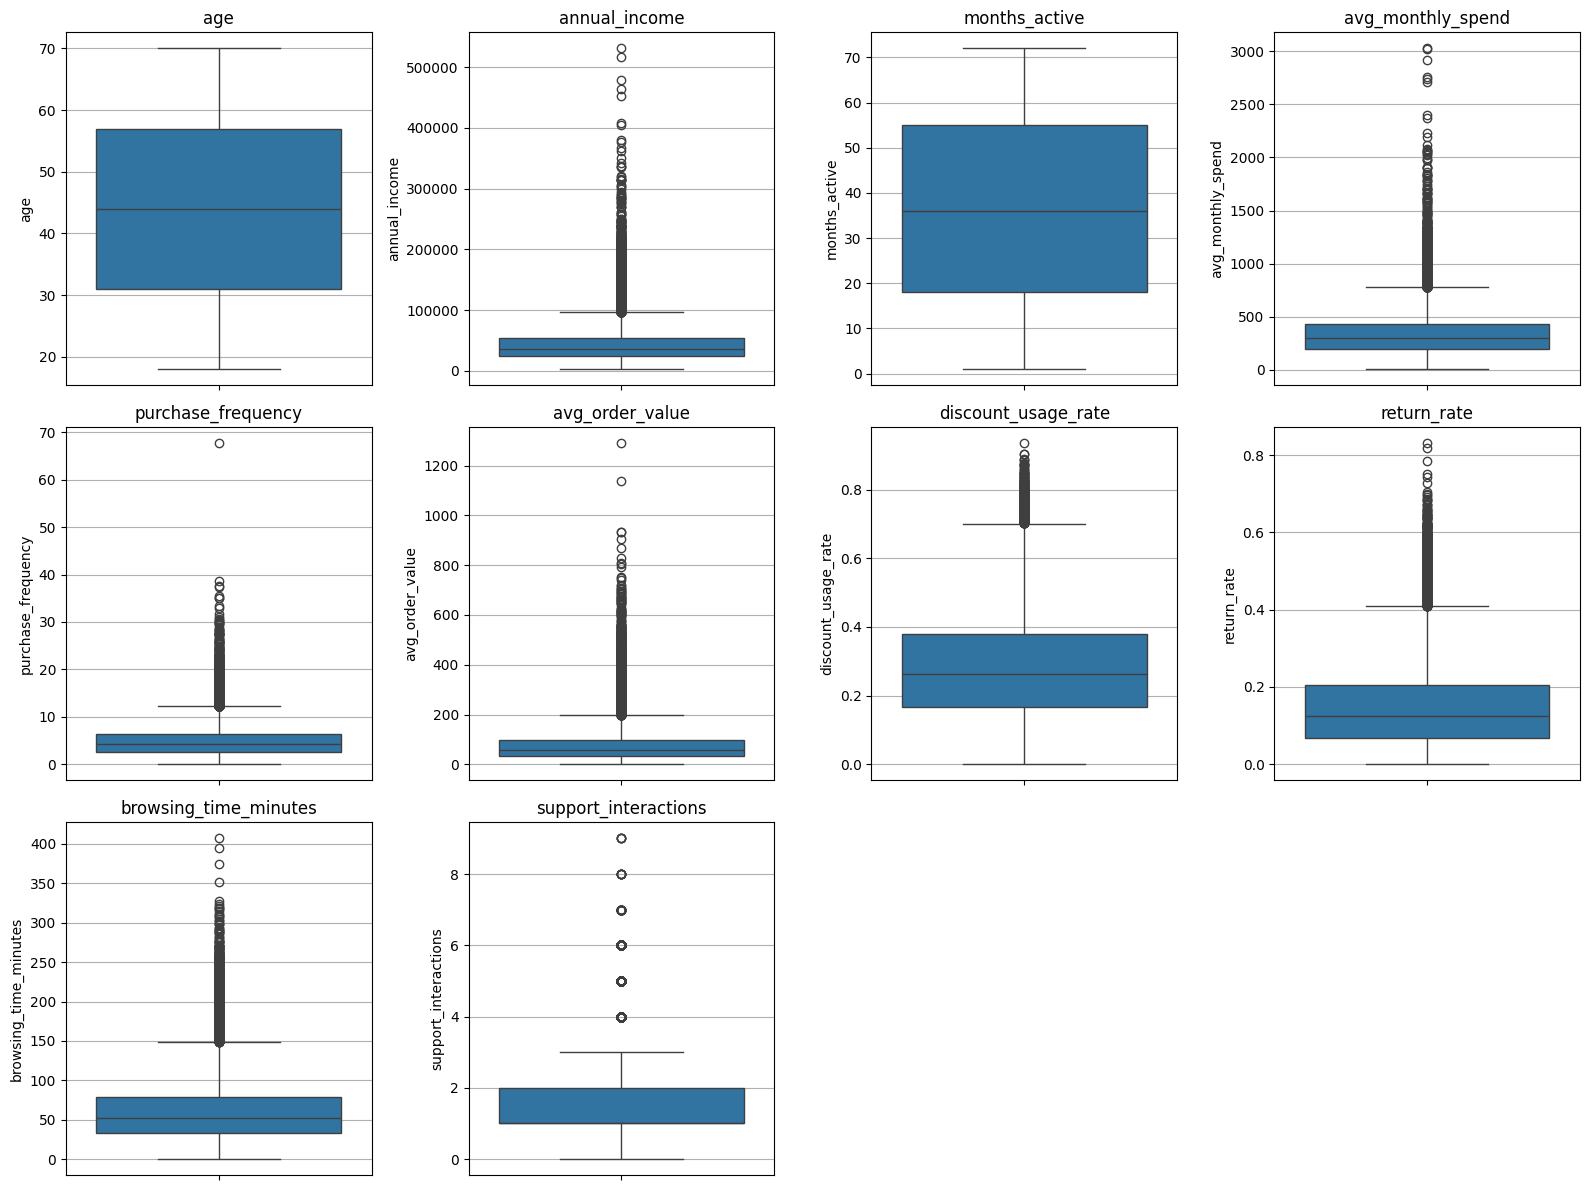

In [30]:
rows = (len(num_cols) + 3) // 4
_, axes = plt.subplots(rows, 4, figsize=(16, 4 * rows))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.boxplot(df, y=col, ax=ax)
    ax.set_title(col)
    ax.grid(axis='y')

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Although we can see some extreme values in the max values compared to its median for most of the columns except age and months active, we will not deal with them for now as they all seem reasonable enough to happen in real life and not from the result of an error.

- Keeping them in our dataset could also be beneficial as they can help us identify high-value customers and their characteristics, which is important for customer segmentation.

---

# **Exploratory Data Analysis**

Finding the relationship between columns and identifying potential patterns in the data that can help us in customer segmentation

Before looking into potential meaningful relationships between the columns let's build a matrix that we can get a holistic view of the relationships between all the columns in one place, and then we can look into specific relationships that we find interesting.

In [31]:
from scipy import stats
from scipy.stats import chi2_contingency
import itertools

We want the matrix heatmap to be consistent with valuescranging from 0 to 1 so we will use these metrics for each combination of columns:

- Numerical-Numerical: We will use **Spearman's correlation coefficient** to find monotonic relationships and is not affected by outliers.
- Numerical-categorical: we will use **eta_squared** to find the strength of association between the numerical and categorical variables.
- Categorical-categorical: we will use **Cramer's V** to normalize chi-square values between 0 and 11

In [32]:
# Helper functions to calculate cramers_v and eta_squared

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(r - 1, k - 1))

def eta_squared(numerical, categorical):
    groups = [numerical[categorical == cat].dropna() 
              for cat in categorical.unique()]
    grand_mean = numerical.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total = ((numerical - grand_mean)**2).sum()
    return ss_between / ss_total if ss_total != 0 else 0


In [33]:
all_cols = df.columns.to_list()
all_cols

['age',
 'annual_income',
 'months_active',
 'avg_monthly_spend',
 'purchase_frequency',
 'avg_order_value',
 'discount_usage_rate',
 'return_rate',
 'browsing_time_minutes',
 'support_interactions',
 'payment_method',
 'region',
 'customer_segment']

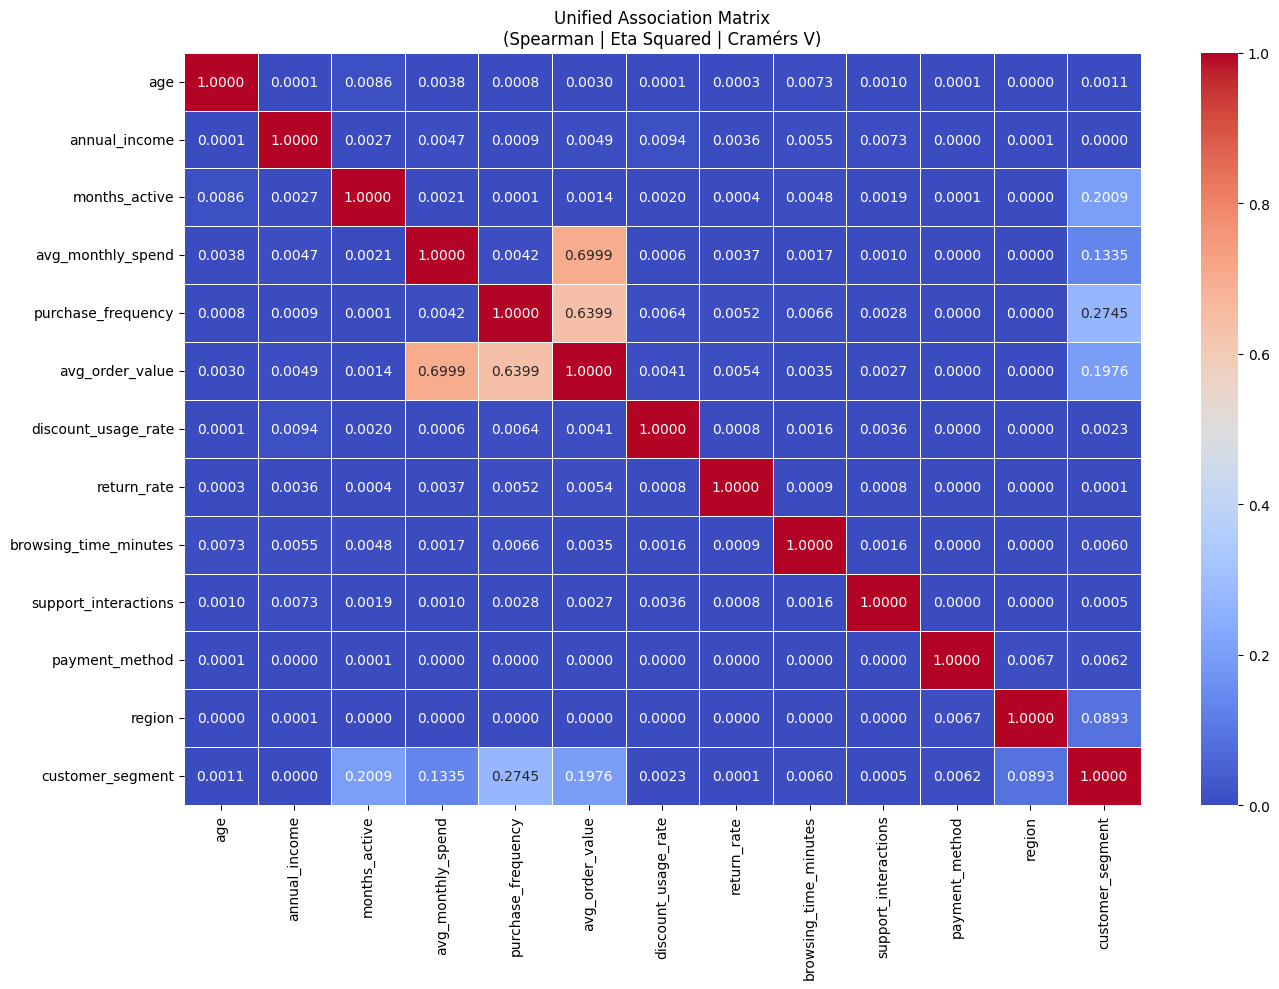

In [34]:
# Build empty matrix
corr_matrix = pd.DataFrame(np.zeros((len(all_cols), len(all_cols))),
                            index=all_cols, columns=all_cols)

# Fill matrix
for col1, col2 in itertools.combinations_with_replacement(all_cols, 2):
    if col1 == col2:
        corr_matrix.loc[col1, col2] = 1.0
    elif col1 in num_cols and col2 in num_cols:
        r, _ = stats.spearmanr(df[col1], df[col2])
        corr_matrix.loc[col1, col2] = abs(r)
        corr_matrix.loc[col2, col1] = abs(r)
    elif col1 in cat_cols and col2 in cat_cols:
        v = cramers_v(df[col1], df[col2])
        corr_matrix.loc[col1, col2] = v
        corr_matrix.loc[col2, col1] = v
    else:
        num = col1 if col1 in num_cols else col2
        cat = col1 if col1 in cat_cols else col2
        eta2 = eta_squared(df[num], df[cat][df[num].notna()])
        corr_matrix.loc[num, cat] = eta2
        corr_matrix.loc[cat, num] = eta2

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.4f', cmap='coolwarm',
            vmin=0, vmax=1, linewidths=0.5)
plt.title('Unified Association Matrix\n(Spearman | Eta Squared | Cramérs V)')
plt.tight_layout()
plt.show()

In [35]:
corr_matrix

,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions,payment_method,region,customer_segment
age,1.000000,0.000090,0.008631,0.003790,0.000827,0.002969,0.000077,0.000275,0.007302,0.001027,0.000072,0.000019,0.001111
annual_income,0.000090,1.000000,0.002740,0.004664,0.000910,0.004871,0.009360,0.003611,0.005544,0.007256,0.000039,0.000060,0.000028
months_active,0.008631,0.002740,1.000000,0.002057,0.000101,0.001396,0.002019,0.000385,0.004807,0.001884,0.000092,0.000042,0.200911
avg_monthly_spend,0.003790,0.004664,0.002057,1.000000,0.004166,0.699946,0.000567,0.003714,0.001732,0.000978,0.000005,0.000008,0.133454
purchase_frequency,0.000827,0.000910,0.000101,0.004166,1.000000,0.639860,0.006392,0.005245,0.006583,0.002842,0.000006,0.000010,0.274467
avg_order_value,0.002969,0.004871,0.001396,0.699946,0.639860,1.000000,0.004106,0.005362,0.003534,0.002727,0.000002,0.000005,0.197603
discount_usage_rate,0.000077,0.009360,0.002019,0.000567,0.006392,0.004106,1.000000,0.000785,0.001555,0.003647,0.000020,0.000032,0.002259
return_rate,0.000275,0.003611,0.000385,0.003714,0.005245,0.005362,0.000785,1.000000,0.000908,0.000751,0.000039,0.000011,0.000054
browsing_time_minutes,0.007302,0.005544,0.004807,0.001732,0.006583,0.003534,0.001555,0.000908,1.000000,0.001558,0.000014,0.000037,0.005952
support_interactions,0.001027,0.007256,0.001884,0.000978,0.002842,0.002727,0.003647,0.000751,0.001558,1.000000,0.000026,0.000027,0.000499


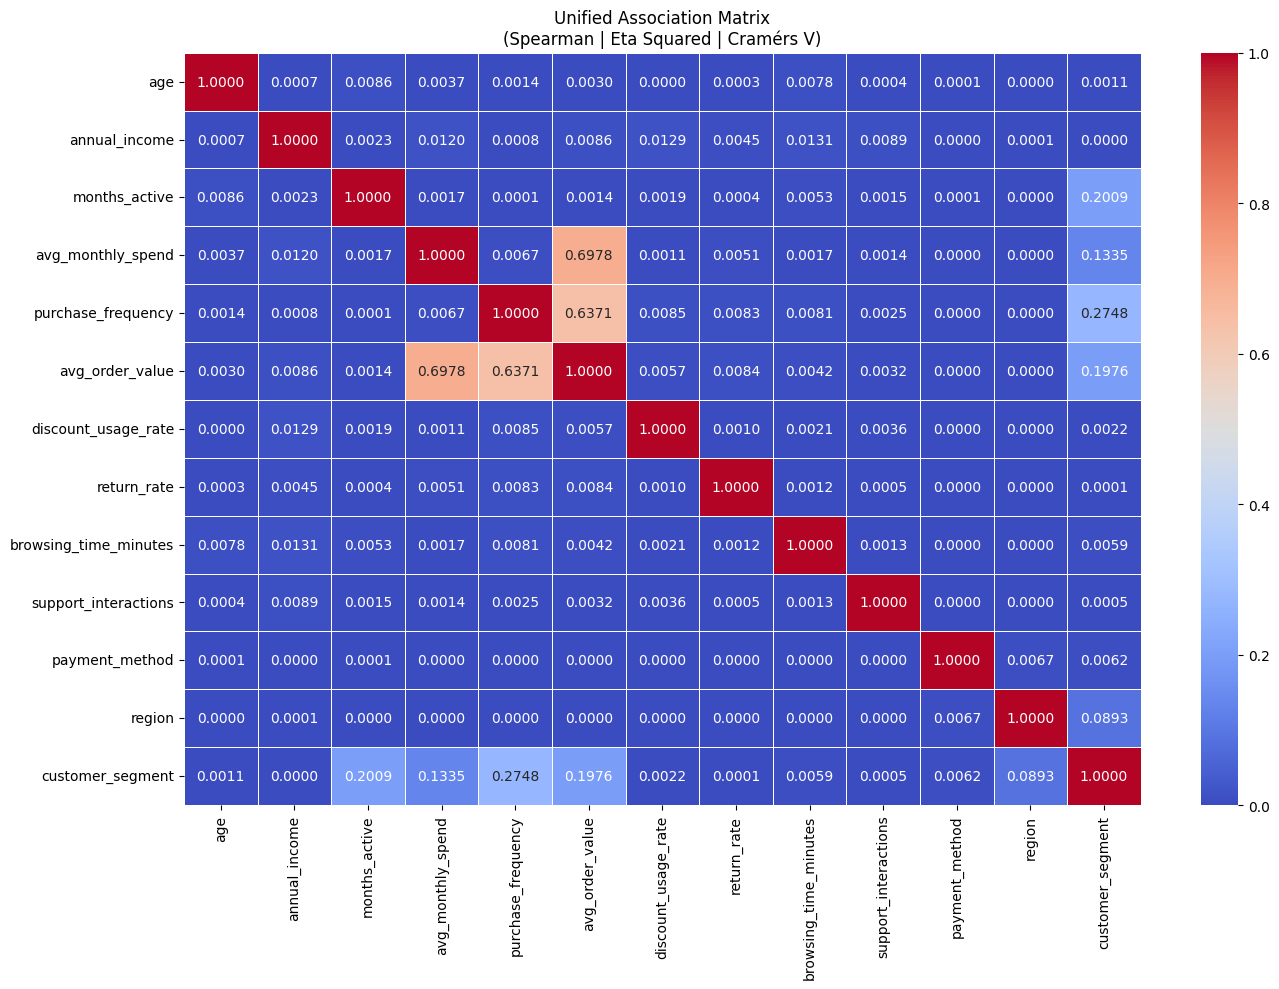

In [36]:
# Build empty matrix
corr_matrix_iterative = pd.DataFrame(np.zeros((len(all_cols), len(all_cols))),
                            index=all_cols, columns=all_cols)

# Fill matrix
for col1, col2 in itertools.combinations_with_replacement(all_cols, 2):
    if col1 == col2:
        corr_matrix_iterative.loc[col1, col2] = 1.0
    elif col1 in num_cols and col2 in num_cols:
        r, _ = stats.spearmanr(cleaned[col1], cleaned[col2])
        corr_matrix_iterative.loc[col1, col2] = abs(r)
        corr_matrix_iterative.loc[col2, col1] = abs(r)
    elif col1 in cat_cols and col2 in cat_cols:
        v = cramers_v(cleaned[col1], cleaned[col2])
        corr_matrix_iterative.loc[col1, col2] = v
        corr_matrix_iterative.loc[col2, col1] = v
    else:
        num = col1 if col1 in num_cols else col2
        cat = col1 if col1 in cat_cols else col2
        eta2 = eta_squared(cleaned[num], cleaned[cat][cleaned[num].notna()])
        corr_matrix_iterative.loc[num, cat] = eta2
        corr_matrix_iterative.loc[cat, num] = eta2

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix_iterative, annot=True, fmt='.4f', cmap='coolwarm',
            vmin=0, vmax=1, linewidths=0.5)
plt.title('Unified Association Matrix\n(Spearman | Eta Squared | Cramérs V)')
plt.tight_layout()
plt.show()

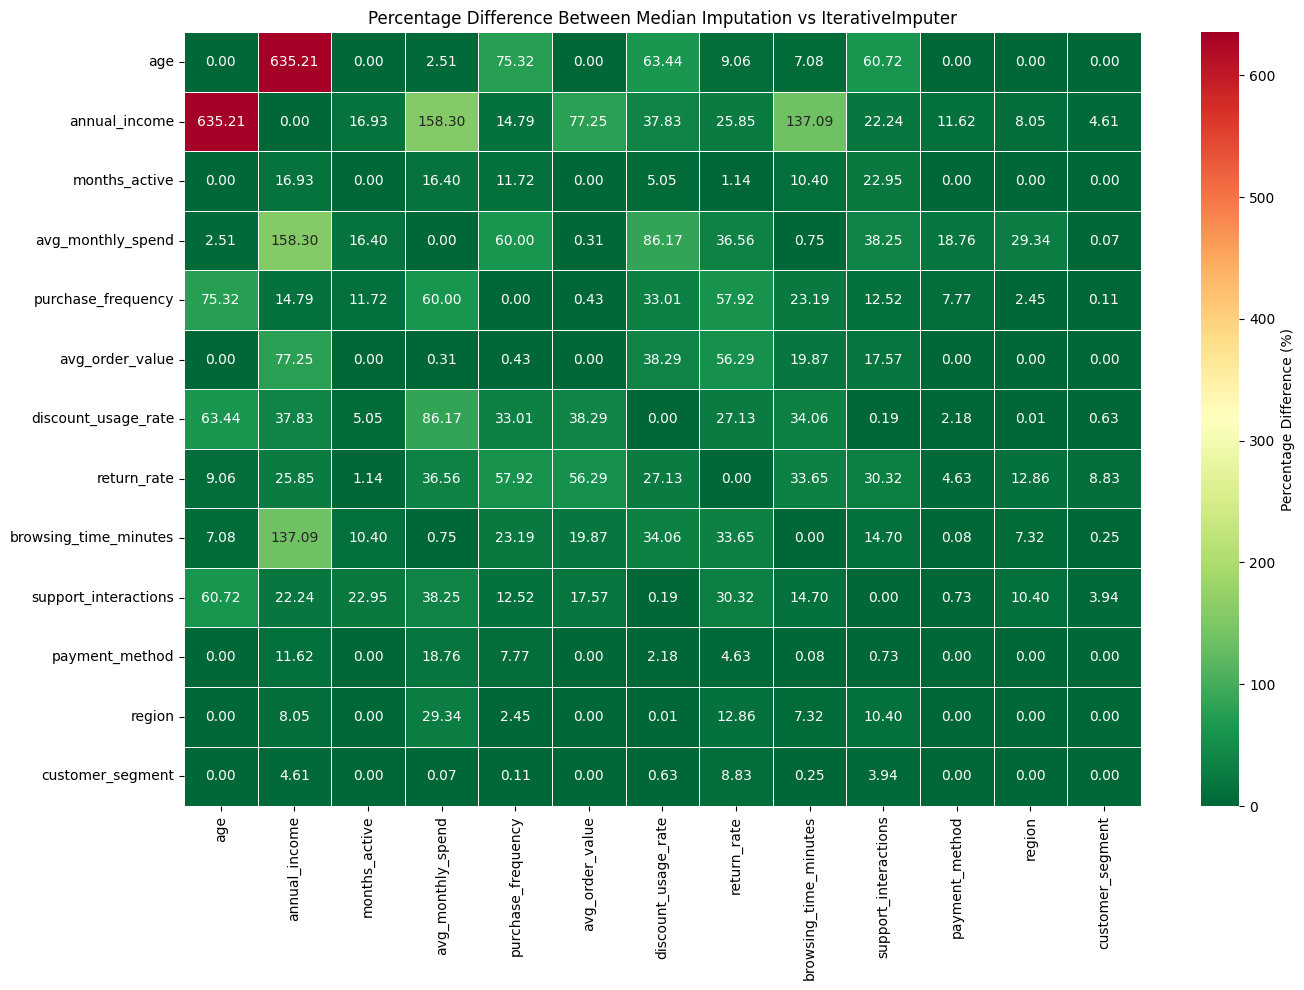

In [37]:
# Calculate percentage difference
# Avoid division by zero
pct_diff = np.where(
    corr_matrix != 0,
    (abs(corr_matrix - corr_matrix_iterative) / abs(corr_matrix)) * 100,
    0
)

pct_diff_matrix = pd.DataFrame(pct_diff, index=all_cols, columns=all_cols)

plt.figure(figsize=(14, 10))
sns.heatmap(pct_diff_matrix, annot=True, fmt='.2f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': 'Percentage Difference (%)'})
plt.title('Percentage Difference Between Median Imputation vs IterativeImputer')
plt.tight_layout()
plt.show()

Very identical heatmap to the Simple Median Imputation

Except for `age` and `annual_income`. They might have meaningful relationships. 

Let's see if we want to switch to `IterativeImputer` or not.

### Numerical-Numerical Relationships Scatterplots

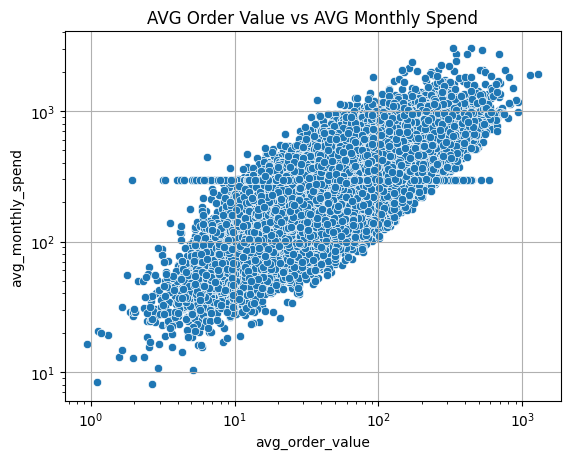

In [38]:
sns.scatterplot(data=df, x='avg_order_value', y='avg_monthly_spend')
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.title("AVG Order Value vs AVG Monthly Spend")
plt.show()

From the graph we see a positive linear relationship between avg_order_value and avg_monthly_spend meaning that as the average order value increases, the average monthly spend also increases, which is expected as the more a customer spends on average per order, the more those valyes add up to the montly spend.

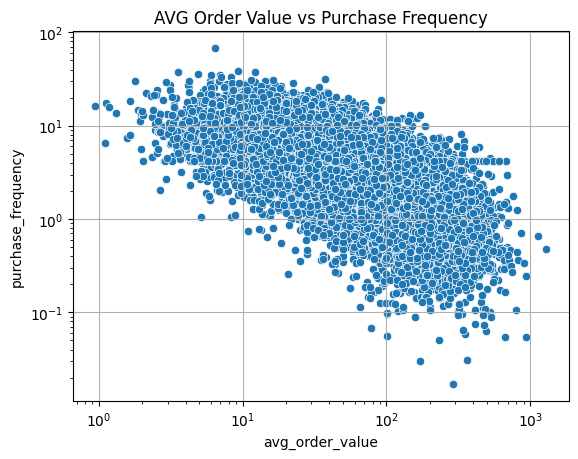

In [39]:
sns.scatterplot(data=df, x='avg_order_value', y='purchase_frequency')
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.title("AVG Order Value vs Purchase Frequency")
plt.show()

From this we seem to see a negative linear relationship between avg_order_value and purchase_frequency, which is interesting as this could indicate that customers who make more frequent purchases tend to have lower average order values, or there might be some other underlying factor at play.

From these two visualizations, it seems The Average Order Value of a customer is postively correlated with their Average Monthly Spend, and negatively correlated with their Purchase Frequency. 

But from the column description, we know that **avg_order_value is calculated by dividing avg_monthly_spend by purchase_frequency**, so these relationships are expected and make sense mathematically as well.

### **Studying our Target Label Relationship**

Because our target label is categorical, we will look into the relationship between it and the numerical columns using grouped boxplots, and with the categorical columns using stacked countplots.

In [40]:
# Define segment order (can be dict or list)
segment_order = ['Occasional', 'Regular', 'Loyal', 'High_Value']

# Or as a dict if you want more metadata:
# segment_order_dict = {
#     'Occasional': 0,
#     'Regular': 1,
#     'Loyal': 2,
#     'High_Value': 3
# }

### Numerical-Categorical Relationship with Grouped Boxplots


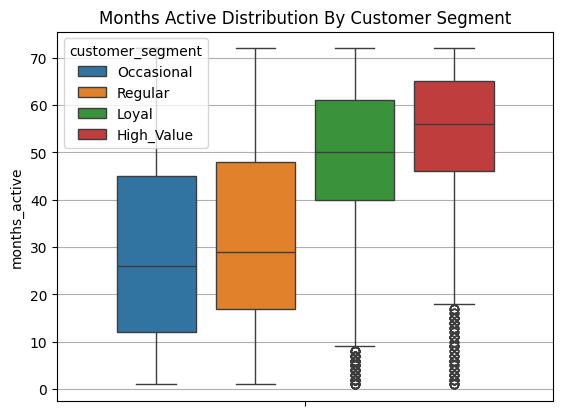

In [41]:
sns.boxplot(df, y='months_active', hue='customer_segment', gap=0.2, hue_order=segment_order)
plt.title("Months Active Distribution By Customer Segment")
plt.grid(axis='y')
plt.show()

We can visually see a difference in the distribution of the numerical columns across the different categories of the target label, which indicates that there is a relationship between them.

- Customers in the 'High Value' segment tend to have been active for a longer time within around 47-65 months, followed by Loyal customer segment with around 40-61 months, and then the 'regular' segment with around 18-48 months, and occasional customers with around 12-45 months.

- Notably, the high value and loyal customer segments also have outliers that have been active for shorter amount of time, which could indicate that they have other behaviors that make them high value or loyal customers despite being active for a shorter time.

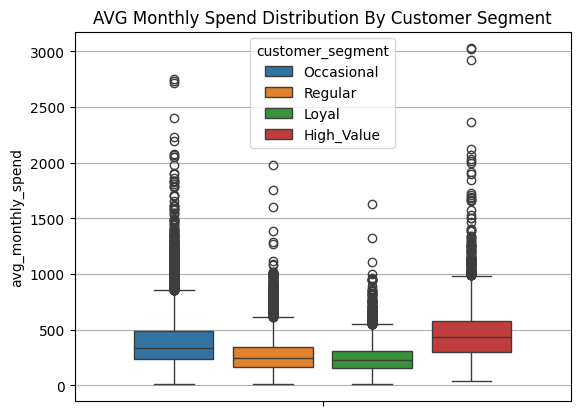

In [42]:
sns.boxplot(df, y='avg_monthly_spend', hue='customer_segment', gap=0.2, hue_order=segment_order)
plt.title("AVG Monthly Spend Distribution By Customer Segment")
# plt.yscale('log')
plt.grid(axis='y')
plt.show()

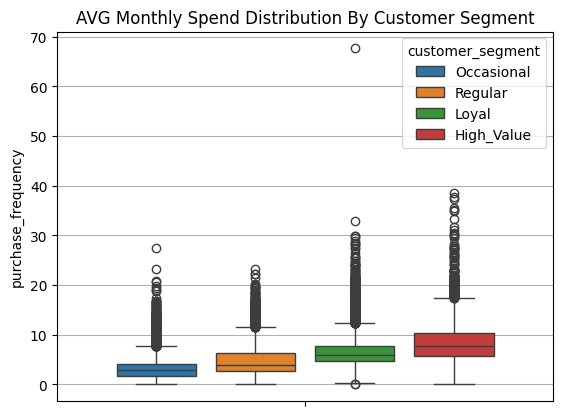

In [43]:
sns.boxplot(df, y='purchase_frequency', hue='customer_segment', gap=0.2, hue_order=segment_order)
plt.title("AVG Monthly Spend Distribution By Customer Segment")
# plt.yscale('log')
plt.grid(axis='y')
plt.show()

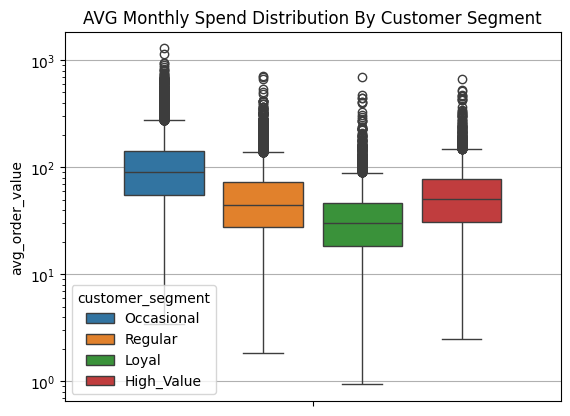

In [44]:
sns.boxplot(df, y='avg_order_value', hue='customer_segment', gap=0.2, hue_order=segment_order)
plt.title("AVG Monthly Spend Distribution By Customer Segment")
plt.yscale('log')
plt.grid(axis='y')
plt.show()

Spending **doesn't really** affect their status, according to this graph 

### Categorical-Categorical Relationship with Stacked Countplots 

In [45]:
fig1 = px.histogram(df, x='customer_segment', color='region', category_orders={'customer_segment': segment_order})
fig1.update_layout(width=600, height=400, title='Customer Segment By Region')
fig1.show()

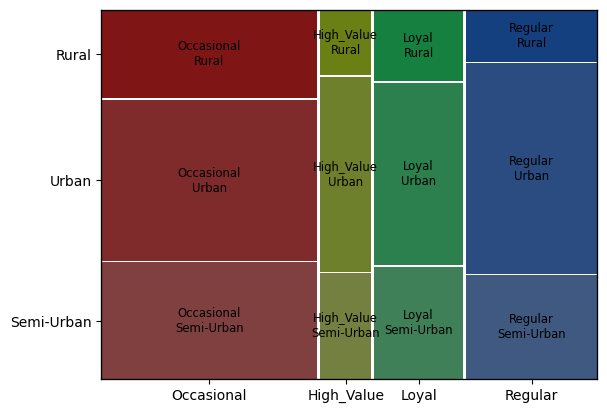

In [46]:
from statsmodels.graphics.mosaicplot import mosaic

mosaic(df, ['customer_segment', 'region'])
plt.show()

`region` doesn't make much of a difference for customer segmentation.

# Don't Forget to Study Customer Behavior!!!!

Insight: The segmentation logic is behavior-driven and influenced by nonlinear feature interactions. (From the Author, but can make good insights from ML)

<Axes: xlabel='return_rate'>

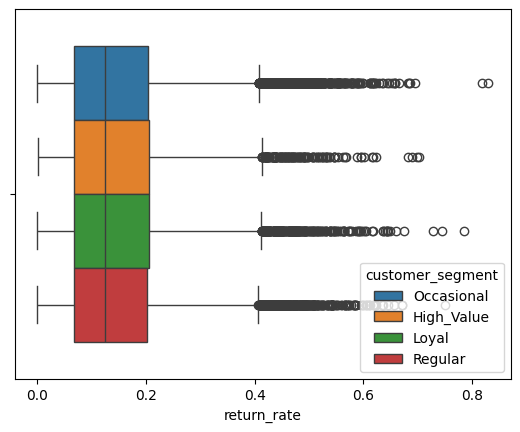

In [47]:
sns.boxplot(df, x='return_rate', hue='customer_segment')

Nor does `return_rate`

<Axes: ylabel='browsing_time_minutes'>

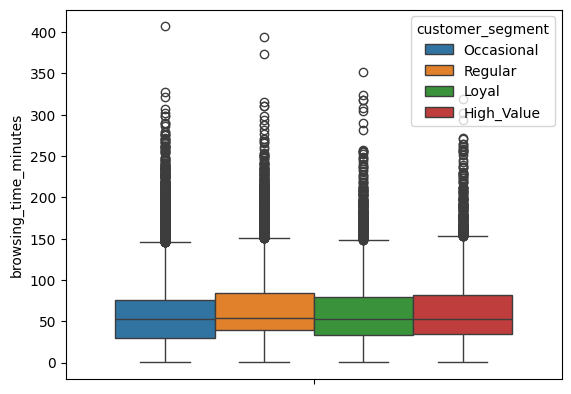

In [48]:
sns.boxplot(df, y='browsing_time_minutes', hue='customer_segment', hue_order=segment_order)

<Axes: ylabel='discount_usage_rate'>

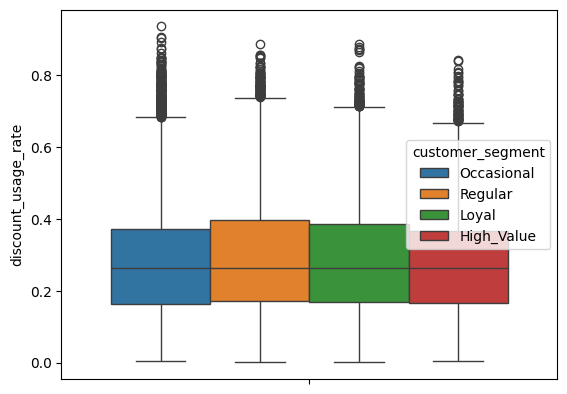

In [49]:
sns.boxplot(df, y='discount_usage_rate', hue='customer_segment', hue_order=segment_order)

<Axes: ylabel='annual_income'>

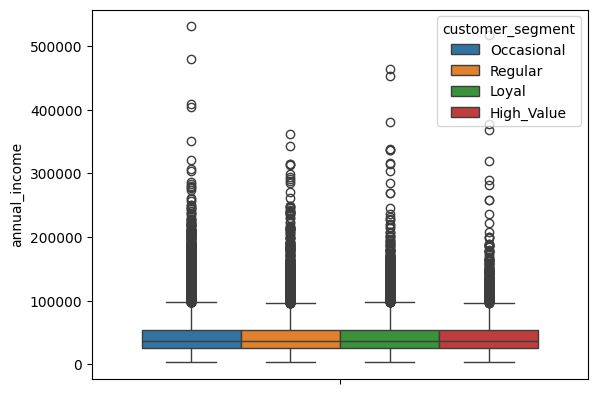

In [50]:
sns.boxplot(df, y='annual_income', hue='customer_segment', hue_order=segment_order)

### Model Development yayyyyyy

In [51]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [52]:
X = df.drop('customer_segment', axis=1)
y = df['customer_segment']

# Train-Test Split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20,           # 20% for test
    random_state=42,
    stratify=y                # Maintain class distribution
)

print(f"Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

Train: 40000 (80.0%)
Test: 10000 (20.0%)


In [53]:
# One Hot Encode
cat_cols = ['payment_method', 'region']

encoder = OneHotEncoder(sparse_output=False, dtype='int64', drop='first')
encoder.fit(X_train[cat_cols])

# Transform both sets
X_train_encoded = encoder.transform(X_train[cat_cols])
X_test_encoded = encoder.transform(X_test[cat_cols])

# Concat the encoded to the X_train and test
X_train_final = pd.concat([
    X_train[num_cols].reset_index(drop=True),
    pd.DataFrame(X_train_encoded, columns=encoder.get_feature_names_out(cat_cols))
], axis=1)

X_test_final = pd.concat([
    X_test[num_cols].reset_index(drop=True),
    pd.DataFrame(X_test_encoded, columns=encoder.get_feature_names_out(cat_cols))
], axis=1)

In [54]:
X_train_final

,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions,payment_method_UPI,payment_method_Wallet,region_Semi-Urban,region_Urban
0,37,37020.749390,57,85.582822,5.724549,12.726923,0.291526,0.359331,118.413682,0.0,0,0,0,0
1,30,28418.213060,2,386.284556,3.815176,80.222308,0.232820,0.031281,41.348445,1.0,0,0,1,0
2,56,64194.919183,3,248.725785,4.285777,47.055674,0.288422,0.115501,52.679175,0.0,1,0,0,0
3,48,36787.730010,59,108.475708,1.833895,38.277961,0.110703,0.096123,52.679175,3.0,0,0,0,1
4,25,22098.203370,60,129.268467,8.990757,12.938806,0.371200,0.072731,157.087060,0.0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,56,158583.024062,67,478.376806,3.716135,101.434086,0.235549,0.081314,16.518861,0.0,1,0,0,1
39996,33,14156.872057,13,46.442089,2.305552,14.049721,0.192057,0.168565,46.035610,1.0,1,0,0,0
39997,59,32082.621550,64,17.006220,5.594805,2.578730,0.058729,0.039171,73.487697,2.0,0,0,0,1
39998,59,29806.287313,42,514.144904,4.008779,102.648760,0.244997,0.313558,78.084745,1.0,0,0,1,0


In [55]:
# Scale data :))

# Fit scaler on training data only
scaler = StandardScaler()
scaler.fit(X_train_final)

# Transform both sets
X_train_final = scaler.transform(X_train_final)
X_test_final = scaler.transform(X_test_final)


In [56]:
# Import models
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Gaussian Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss'),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=0)
}

params = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10],    # Inverse of Strength of regularization (1/alpha)
        'solver': ['lbfgs', 'liblinear'], 
        'max_iter': [1000, 2000]
    },
    'Gaussian Naive Bayes': {
        'var_smoothing': [1e-9]
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    'Decision Tree': {
        'max_depth': [5, 10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }, 
    'Random Forest': {
        'n_estimators': [50, 100, 150],
        'max_depth': [10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
   'XGBoost': {
        'n_estimators': [50, 100, 150],
        'max_depth': [5, 7, 10],
        'learning_rate': [0.01, 0.1, 0.3],
        'subsample': [0.8, 1.0]
    },
    'CatBoost': {
        'iterations': [50, 100, 150],
        'depth': [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1]
    }
}

# Train all models
results = {}
 
print("="*70)
print("TRAINING ALL MODELS WITH GRIDSEARCHCV")
print("="*70)

for model_name in models.keys():
    print(f"\n🔄 Training {model_name}...")
    
    grid_search = GridSearchCV(
        models[model_name],
        params[model_name],
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=0
    )
    
    grid_search.fit(X_train_final, y_train)
    
    results[model_name] = {
        'model': grid_search.best_estimator_,
        'best_params': grid_search.best_params_,
        'cv_score': grid_search.best_score_,
        'test_score': grid_search.score(X_test_final, y_test)
    }
    
    print(f"✓ CV Score: {grid_search.best_score_:.4f} | Test Score: {grid_search.score(X_test_final, y_test):.4f}")

# Voting Classifier
print(f"\n🔄 Training Voting Classifier...")
voting_clf = VotingClassifier(
    estimators=[
        ('rf', results['Random Forest']['model']),
        ('xgb', results['XGBoost']['model']),
        ('cb', results['CatBoost']['model'])
    ],
    voting='soft'
)
voting_clf.fit(X_train_final, y_train)

results['Voting Classifier'] = {
    'model': voting_clf,
    'best_params': 'Ensemble (RF + XGB + CatBoost)',
    'cv_score': None,
    'test_score': voting_clf.score(X_test_final, y_test)
}
print(f"✓ Test Score: {voting_clf.score(X_test_final, y_test):.4f}")

# Summary
print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)

summary_df = pd.DataFrame({
    'Model': results.keys(),
    'CV Score': [results[m]['cv_score'] if results[m]['cv_score'] is not None else np.nan for m in results.keys()],
    'Test Score': [results[m]['test_score'] for m in results.keys()]
})

summary_df = summary_df.sort_values('Test Score', ascending=False).reset_index(drop=True)
print(summary_df.to_string(index=False))

TRAINING ALL MODELS WITH GRIDSEARCHCV

🔄 Training Logistic Regression...
✓ CV Score: 0.6365 | Test Score: 0.6362

🔄 Training Gaussian Naive Bayes...
✓ CV Score: 0.5739 | Test Score: 0.5791

🔄 Training KNN...
✓ CV Score: 0.6376 | Test Score: 0.6477

🔄 Training Decision Tree...
✓ CV Score: 0.7302 | Test Score: 0.7277

🔄 Training Random Forest...
✓ CV Score: 0.7553 | Test Score: 0.7592

🔄 Training XGBoost...


ValueError: 
All the 270 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
270 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\eungl\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\eungl\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py", line 774, in inner_f
    return func(**kwargs)
  File "c:\Users\eungl\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\sklearn.py", line 1758, in fit
    raise ValueError(
    ...<2 lines>...
    )
ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2